In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install pyarrow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

ruta_figuras = "../figures"

In [3]:
# Carga
df = pd.read_csv("../data/raw/dataset.csv")
print("Los datos se han cargado correctamente.")
print(df.head())

Los datos se han cargado correctamente.
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Agai

In [4]:
filas_iniciales = df.shape[0]

print("=== DIAGNÓSTICO INICIAL ===")
print(f"Filas: {filas_iniciales:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

=== DIAGNÓSTICO INICIAL ===
Filas: 114,000
Columnas: 21

Tipos de datos:
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

Valores nulos por columna:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness

# Explicación del Dataset

Este datasets contiene 114.000 filas y 21 columnas.

Cada fila representa una canción mientras que las columnas son variables de estas: metadatos como nombre, artista o álbum, características musicales e información categórica o adicional de estas.

Las variables son las siguientes:

- **Unnamed: 0**: identificador de fila. No tiene utilidad alguna por lo que se eliminará durante el preprocesado (int).

- **Track_id**: es el identificador único de la canción. Debemos mantener valores únicos de esta columna en el dataset para el posterior análisis (string - código alfanumérico).
- **Artists**: contiene todos los artistas asociados a la canción en formato de cadena de texto, separando cada artista mediante el caracter ';' (string - texto).
- **Album_name**: nombre del álbum al que pertence la canción. Variable meramente informatia, útil para la visualización de datos en el sistema de recomendación (string - texto).
- **Track_name**: nombre de la canción. No tiene utilidad directa para el análisis multivariante, pero será necesaria en el sistema de recomednación para mostrar resultados comprensibles al usuario (string - texto).
- **Popularity**: popularidad de la canción medida de 0 a 100 (menos a más popular). La popularidad depende del momento en el que se recogen los datos, puede cambiar con el tiempo (int).
- **Duration_ms**: Duración de la canción en milisegundos (int).
- **Explicit**: variable que indica si la canción contiene contenido explícito en su letra (booleana).
- **Danceability**: mide  lo bailable que es una canción, teniendo en cuenta tempo, estabilidad rítmica, fuerza del beat y regularidad, siendo 0 nada bailable y 1 muy bailable (float).
- **Energy**: intensidad y actividad de la canción, depende de la rapidez, ruidosidad y agresividad. Se mide de 0 a 1 (poco enérgica a muy enérgica) (float).
- **Key**: tonalidad de la canción codificada de forma numérica. Hay 12 valores diferntes (del 0 al 11) correspondientes a las diferentes tonalidades posibles (int).
- **Loudness**: sonoridad media de la canción , medida en decibelios a escala completa (dBFS), métrica muy usada en audio digital. Los valores suelen estar entre -60 y 0 dB, siendo 0 el límite máximo antes de la saturación (pueden existir valores por encima pero en audio digital causan distorsión). Sigue una escala logarítmica, una reducción de -3 dB supone una pérdida de la mitad de la energía, pero el oído humano no lo percibe como la mitad del volumen (float).
- **Mode**: variable binaria que indica el modo de la canción (0 = menor, 1 = mayor) (int).
- **Speechiness**: presencia de palabras habladas medida en escala de 0 a 1. Valores bajos indican música (clásica, instrumental...) mientras que valores altos indican habla (podcast, rap...). Spotify considera > 0,66 como probablemente hablado; 0,33 - 0,66 como mezcla de música y habla; < 0,33 musical (float).
- **Acousticness**: probabilidad o confianza de que una canción sea acústica (utiliza instrumentos tradicionales como guitarras de madera o pianos, sin elementos electrónicos o sintetizadores). Valores cercanos a 1 indican alta probabilidad de que la canción sea acústica por lo que valores cercanos a 0 reflejan baja probabilidad (float).
- **Instrumentalness**: probabilidad de que la canción no tenga voces. Valores cercanos a 1 indican mayor probabilidad de que la canción sea instrumental (float).
- **Liveness**: probabilidad de que haya público o de que sea una grabación en directo. Valores cercanos a 1 indican mayor probabilidad de música en directo (float).
- **Valence**: positividad musical percibida. Valores cercanos a 1 indican música alegre, eufórica o motivadora mientras que valores cercanos a 0 indican tristeza, oscuridad, negatividad o enfado (float).
- **Tempo**: velocidad estimada de la canción, medida en beats por minuto o BPM (pulso rítmico por minuto). En torno a 90 BPM se considera lento, 120 BPM se considera estándar bailable y 160 BPM se considera rápido (float).
- **Time_signature**: indica el compás de la canción, a rasgos generales. Hay 5 posibles categorías: sin ritmo, ritmo libre, ternario, cuaternario o irregular. Cada categoría está representada por un número diferente (int).
- **Track_genre**: género musical con el que se etiqueta la canción (string).



In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


In [6]:
#Eliminar columna índice
df = df.drop(columns = ["Unnamed: 0"])

print(f"Variable índice eliminada")

Variable índice eliminada


In [7]:
# Eliminar filas con valores nulos 
df = df.dropna()
print(f"Canciones con valores nulos eliminadas")
print(f"Quedan {df.shape[0]:,} canciones")

Canciones con valores nulos eliminadas
Quedan 113,999 canciones


In [8]:
#Búsqueda de duplicados exactos
print(f"\nNúmero de duplicados exactos: {df.duplicated().sum():,}")

#Eliminamos los duplicados exactos
df = df.drop_duplicates(keep = "first").copy()
print("Duplicados exactos eliminados")



Número de duplicados exactos: 450
Duplicados exactos eliminados


In [9]:
#Búsqueda de duplicados de Track ID
print(f"Filas implicadas en canciones repetidas: {df['track_id'].duplicated(keep = False).sum():,}")
print(f"Número de canciones implicadas: {df[df["track_id"].duplicated(keep = False)]["track_id"].nunique():,}\n")

conteo_tracks = df["track_id"].value_counts()
tracks_repetidos = conteo_tracks[conteo_tracks > 1]

distribucion_df = (
    tracks_repetidos
    .value_counts()
    .sort_index()
    .rename_axis("num_filas_por_track_id")
    .reset_index(name="num_track_ids")
)

distribucion_df["filas_implicadas"] = (
    distribucion_df["num_filas_por_track_id"] *
    distribucion_df["num_track_ids"]
)

print(distribucion_df)

print(f"Total filas implicadas: {distribucion_df["filas_implicadas"].sum():,}")
print(f"Total track_id repetidos: {distribucion_df["num_track_ids"].sum():,}\n")

#Comprobación de las columnas que generan esas diferencias en track_id
nunique_por_track = df.groupby("track_id").nunique(dropna=False)

resumen = pd.DataFrame({
    "hay_diferencias": nunique_por_track.gt(1).any(),
    "num_track_ids_con_diferencias": nunique_por_track.gt(1).sum()
})

print(resumen)
print("\n")

flags = pd.DataFrame({
    "cambia_track_genre": nunique_por_track["track_genre"] > 1,
    "cambia_popularity": nunique_por_track["popularity"] > 1
})

print(flags.value_counts())


Filas implicadas en canciones repetidas: 40,108
Número de canciones implicadas: 16,299

   num_filas_por_track_id  num_track_ids  filas_implicadas
0                       2          11424             22848
1                       3           2955              8865
2                       4           1361              5444
3                       5            431              2155
4                       6            104               624
5                       7             21               147
6                       8              2                16
7                       9              1                 9
Total filas implicadas: 40,108
Total track_id repetidos: 16,299

                  hay_diferencias  num_track_ids_con_diferencias
artists                     False                              0
album_name                  False                              0
track_name                  False                              0
popularity                   True                       

In [10]:
df = (
    df.groupby("track_id")
      .agg({
          "artists": "first",
          "album_name": "first",
          "track_name": "first",
          "popularity": "max",
          "duration_ms": "first",
          "explicit": "first",
          "danceability": "first",
          "energy": "first",
          "key": "first",
          "loudness": "first",
          "mode": "first",
          "speechiness": "first",
          "acousticness": "first",
          "instrumentalness": "first",
          "liveness": "first",
          "valence": "first",
          "tempo": "first",
          "time_signature": "first",
          "track_genre": lambda x: sorted(set(x))
      })
      .reset_index()
)

df = df.rename(columns={"track_genre": "genres"})

In [11]:
# Género primario (el primero que aparece) para modelos que necesiten uno solo
df["main_genre"] = df["genres"].apply(lambda x: x[0])

# Número de géneros por canción
df["n_genres"] = df["genres"].apply(len)

In [12]:
#Mostrar valores tras eliminar duplicados
ncanciones = df.shape[0]
print(f"Canciones únicas: {ncanciones:,}")
print(f"Número de duplicados: {df["track_id"].duplicated().sum()}")
print(f"\nDistribución del número de canciones por género principal:")
print(df["main_genre"].value_counts().sort_index())
print(f"\nDistribución de número de géneros por canción:")
print(df["n_genres"].value_counts().sort_index())
print(f"\nDescriptiva del número de géneros:\n {df["n_genres"].describe()}")

Canciones únicas: 89,740
Número de duplicados: 0

Distribución del número de canciones por género principal:
main_genre
acoustic       1000
afrobeat        999
alt-rock        999
alternative     407
ambient         999
               ... 
techno          416
trance          708
trip-hop        904
turkish         870
world-music     923
Name: count, Length: 113, dtype: int64

Distribución de número de géneros por canción:
n_genres
1    73441
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1
Name: count, dtype: int64

Descriptiva del número de géneros:
 count    89740.000000
mean         1.265311
std          0.664207
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
Name: n_genres, dtype: float64


## DUPLICADOS POR TRACK_NAME + ARTISTS

In [13]:
#Búsqueda de duplicados de Nombre de la canción + Artista con álbum/track_id diferente
cols_id = ["track_name", "artists"]

conteo_tracks_artists = df[cols_id].value_counts()
print("Las canciones + artista más repetidas son:")
print(conteo_tracks_artists.head(10))

repetidas = df[cols_id].duplicated(keep=False)
filas_implicadas = repetidas.sum()
canciones_implicadas = df.loc[repetidas, cols_id].drop_duplicates().shape[0]

print(f"Total filas implicadas: {filas_implicadas:,}")
print(f"Total canciones + artists repetidos: {canciones_implicadas:,}\n")

#Combinaciones de columnas que cambian para la misma cancion+artista
df_rep = df[df[cols_id].duplicated(keep=False)].copy()
cols_revisar = [c for c in df.columns if c not in cols_id]

df_rep_aux = df_rep.copy()
for col in cols_revisar:
    df_rep_aux[col] = df_rep_aux[col].apply(
        lambda x: tuple(x) if isinstance(x, list) else x
    )

nunique_grupo = (
    df_rep_aux
    .groupby(cols_id)[cols_revisar]
    .nunique()
)

cambios_bool = nunique_grupo.gt(1)
firmas = cambios_bool.apply(
    lambda fila: tuple(fila.index[fila].tolist()),
    axis = 1
)

tipos_caso = firmas.value_counts().reset_index()
tipos_caso.columns = ["columnas_que_cambian", "num_canciones"]

print("Combinaciones de columnas que cambian para diferentes cancion + artista")
print(tipos_caso)

firma_objetivo = tipos_caso.loc[3 , "columnas_que_cambian"]
grupos_objetivo = firmas[firmas == firma_objetivo].index

df_caso = (
    df_rep.set_index(cols_id)
    .loc[grupos_objetivo]
    .reset_index()
    .sort_values(cols_id)
)

print(df_caso)


Las canciones + artista más repetidas son:
track_name                                   artists        
Rockin' Around The Christmas Tree            Brenda Lee         45
Little Saint Nick - 1991 Remix               The Beach Boys     41
Run Rudolph Run                              Chuck Berry        40
Frosty The Snowman                           Ella Fitzgerald    34
Let It Snow! Let It Snow! Let It Snow!       Dean Martin        32
Mistletoe                                    Justin Bieber      31
Sleigh Ride                                  Ella Fitzgerald    30
I Saw Mommy Kissing Santa Claus              The Jackson 5      27
Last Last                                    Burna Boy          26
The Christmas Song (Merry Christmas To You)  Nat King Cole      26
Name: count, dtype: int64
Total filas implicadas: 13,054
Total canciones + artists repetidos: 4,657

Combinaciones de columnas que cambian para diferentes cancion + artista
                                  columnas_que_cambia

In [14]:
df = (
df.sort_values("popularity", ascending=False)
.drop_duplicates(subset=cols_id, keep="first")
.reset_index(drop=True)
)

print("Canciones con mismo título + artista eliminadas")

Canciones con mismo título + artista eliminadas


### Preprocesamiento artistas

In [15]:
#Convertir columna artistas en varias columnas
#Columna con lista de artistas
df["artists"] = df["artists"].str.split(";")
#Columna cona rtista principal
df["main_artist"] = df["artists"].apply(lambda x: x[0])
#Columna con número de artistas
df["n_artists"] = df["artists"].apply(len)

In [16]:
print(f"\nDistribución de número de canciones por artista:")
print(df["main_artist"].value_counts().sort_index().sort_values(ascending = False).head(5))
print(f"\nDistribución de número de artistas más recurrentes por canción:")
print(df["n_artists"].value_counts().sort_index())
print(f"\nDescriptiva del número de artistas:\n {df["n_artists"].describe()}")

# Colaboraciones más numerosas
print(f"\nCanciones con más artistas:")
print(df.nlargest(5, "n_artists")[
    ["track_name", "artists", "n_artists"]
])


Distribución de número de canciones por artista:
main_artist
Pritam                     294
George Jones               274
Wolfgang Amadeus Mozart    262
Hank Williams              177
my little airport          163
Name: count, dtype: int64

Distribución de número de artistas más recurrentes por canción:
n_artists
1     61037
2     14106
3      4223
4      1182
5       406
6       162
7        96
8        43
9        19
10       20
11       10
12        6
13        4
14        4
15        4
17        3
18        6
19        1
20        1
22        1
23        3
26        1
30        2
31        1
32        1
38        1
Name: count, dtype: int64

Descriptiva del número de artistas:
 count    81343.000000
mean         1.375177
std          0.883619
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         38.000000
Name: n_artists, dtype: float64

Canciones con más artistas:
                                              track_name  \
4505     

In [17]:
#Resumen de datos
duplicated = df["track_id"].duplicated().sum()
ntracks = df["track_id"].nunique()
nartists = df["main_artist"].nunique()
ngenres = df["main_genre"].nunique()

print(f"Número de duplicados: {duplicated}")
print(f"Filas antes de limpiar: {filas_iniciales:,}")
print(f"Filas después de limpiar: {df.shape[0]:,}")
print(f"Filas eliminadas: {filas_iniciales - df.shape[0]:,}")
print(f"Número de canciones únicas: {ntracks:,}")
print(f"Número de artistas pincipales únicos: {nartists:,}")
print(f"Número de artistas totales únicos: {df["artists"].explode().nunique():,}")
print(f"Número de géneros principales únicos: {ngenres:,}")


Número de duplicados: 0
Filas antes de limpiar: 114,000
Filas después de limpiar: 81,343
Filas eliminadas: 32,657
Número de canciones únicas: 81,343
Número de artistas pincipales únicos: 17,648
Número de artistas totales únicos: 29,859
Número de géneros principales únicos: 113


Tras el proceso inicial de limpieza, el dataset final queda compuesto por 81.343 canciones únicas. La reducción respecto al dataset original de 114.000 registros se debe a tres causas. La primera, la existencia de duplicados exactos en el dataset (filas repetidas con los mismos valores en todas las columnas). La segunda, la existencia de canciones repetidas bajo diferentes géneros. Para evitar que estas canciones tuvieran más peso en los análisis posteriores, han sido agrupadas en una única fila por canción, agrupando la información del género. La tercera, la existencia de canciones con diferencias en alguna columna (track_id, album_name, popularity) pero mismo título y mismo artista. Se ha resuelto manteniendo las filas de las canciones con mayor popularidad así como todos sus valores y eliminando el resto de duplicadas.

Este paso es importante ya que las técnicas como PCA, AFE o clustering trabajan sobre estos datos d forma que si hay canciones repetidas aparecen sobrerrepresentadas artificialmente.

## Transformación de variables

In [18]:
#Transformar valores de columna key en categorías
key_map = {
    0: "C",
    1: "C#/Db",
    2: "D",
    3: "D#/Eb",
    4: "E",
    5: "F",
    6: "F#/Gb",
    7: "G",
    8: "G#/Ab",
    9: "A",
    10: "A#/Bb",
    11: "B"
}

df["key"] = df["key"].map(key_map).astype("category")

In [19]:
#Transformar valores de time_signature en categorías
time_signature_map = {
    0: "Free",
    1: "Free",
    3: "Ternary",
    4: "Quadruple",
    5: "Irregular"
}

df["time_signature"] = df["time_signature"].map(time_signature_map).astype("category")


In [20]:
# Convertir explicit a booleano
df["explicit"] = df["explicit"].astype(bool)
print(f"Explicit es ahora una variable de tipo: {df["explicit"].dtype}")

Explicit es ahora una variable de tipo: bool


In [21]:
#Convertir duration a minutos (más interpretable)
df["duration_min"] = (df["duration_ms"] / 60000).round(2)
df = df.drop(columns = "duration_ms")

In [22]:
#Definir tipos de variables
id_features = ["track_id", "track_name", "main_artist", "main_genre", "artists", "genres", "album_name"]

audio_features_cuant = [
    "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]

audio_features_cat = ["key", "mode", "time_signature"]

control_features_cuant = ["popularity", "duration_min"]
control_features_cat = ["n_artists", "n_genres", "explicit"]

Esta división se considera adecuada ya que divide de forma clara las variables que definen el espacio musical de aquellas que sirven como metadatos, filtros o variables de análisis posterior.

Las variables 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness'. .'instrumentalness', 'liveness', 'valence' y 'tempo', se consideran el conjunto principal de audio features. Estas variables serán candidatas iniciales para construie el primer espacio musical reducido mediante PCA y AFE.

Por otra parte, variables como 'popularity', 'duration_min', 'main_genre', 'genres', 'n_genres', 'explicit', 'main_artist', 'artists', 'n_artists', 'album_name'. 'key', 'mode' y 'time_signature' se mantienen como variables auxiliares. 

Esta separación logra evitar mezclar en el mismo espacio musical variables acústicas con metadatos, etiquetas externas o variables categóricas.

Las variables se organizaron en cuatro grupos: identificadores y metadatos, audio features cuantitativas, audio features categóricas/discretas y variables de control. El primer espacio musical reducido se construirá únicamente a partir de audio features cuantitativas continuas, dejando variables como género, popularidad, duración, artista, tonalidad y compás como variables auxiliares para análisis posterior, filtros del recomendador o experimentos secundarios.

# ANÁLISIS UNIVARIADO

## VARIABLES CATEGÓRICAS


Tabla de frecuencias para key
       Frecuencia  Porcentaje
key                          
G            9650       11.86
C            9289       11.42
D            8578       10.55
A            8217       10.10
C#/Db        7756        9.53
E            6579        8.09
F            6525        8.02
B            6468        7.95
F#/Gb        5531        6.80
A#/Bb        5318        6.54
G#/Ab        4957        6.09
D#/Eb        2475        3.04

Tabla de frecuencias para mode
      Frecuencia  Porcentaje
mode                        
1          51448       63.25
0          29895       36.75

Tabla de frecuencias para time_signature
                Frecuencia  Porcentaje
time_signature                        
Quadruple            71991       88.50
Ternary               6940        8.53
Irregular             1485        1.83
Free                   927        1.14


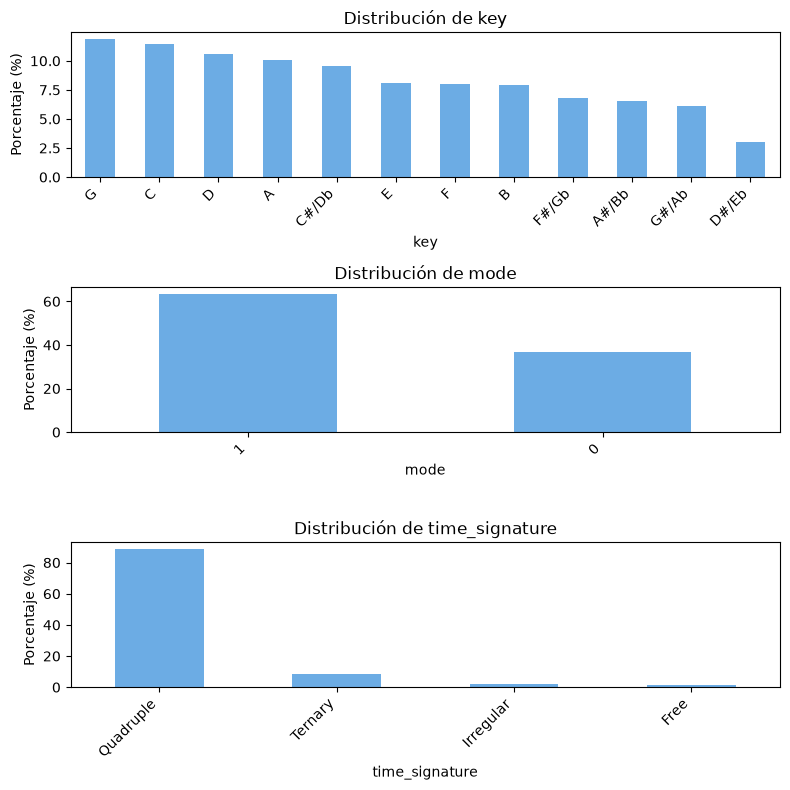

In [23]:
fig, axes = plt.subplots(3,1, figsize=(8, 8))

for i, var in enumerate(audio_features_cat):
    cont = df[var].value_counts()
    porcentajes = df[var].value_counts(normalize=True).round(4) * 100

    tabla_frecuencias = pd.DataFrame({
        "Frecuencia": cont,
        "Porcentaje": porcentajes
    })

    print(f"\nTabla de frecuencias para {var}")
    print(tabla_frecuencias)

    porcentajes.plot(
        kind="bar",
        color="#6CACE4",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Porcentaje (%)")
    axes[i].tick_params(axis="x", rotation=45)

    for label in axes[i].get_xticklabels():
        label.set_ha("right")

fig.tight_layout()

plt.savefig(f"{ruta_figuras}/bar_audio_features_cat.png", dpi=300, bbox_inches="tight")
plt.show()

- **Key**: destaca la presencia de tonalidades como G, C, D, A y C#/Db. Los códigos numéricos antes del mapeo no reflejaban ningun orden o cercanía real entre tonalidades por lo que se han mapeado. Sin embargo, la tonalidad tiene naturaleza circular, pudiendo considerarse la cercanía tonal mediante el círculo de quintas, donde algunas tonalidades están musicalmente más próximas que otras. POdría ser intereseante ubicarlas en el espacio. En primera instancia, no vamos a incluir esta variable en el PCA, pero se podría usar para análisis posteriores y para experimentos (codificación circular/quintas/distribución tonal por cluster...)



- **Mode**: casi el doble de las canciones presentan modo mayor. Esta variable puede estar muy relacionada con sensaciones musicales pero al ser binaria no sería recomendable meterla en el PCA inicialmente. Se podría utilizar para estudiar si determinados clusters tienen mayor presencia de alguno de los modos.




- **Time_signature**: está muy desbalanceada, ya que la categoría quadruple representa el 88,64% dell dataset, lo que indica que la mayoría de canciones comparten una estructura métrica común. Debido a esta baja variabilidad, esta variable no parece muy adecuada pra formar parte del PCA. Aún así, puede conservarse como variable descriptiva o para algún análisis posterior.

## VARIABLES CUANTITATIVAS

### DESCRIPTIVAS

In [24]:
eda_summary = df[audio_features_cuant].describe().T

eda_summary["skewness"] = df[audio_features_cuant].skew()
eda_summary["kurtosis"] = df[audio_features_cuant].kurtosis()

eda_summary

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
danceability,81343.0,0.559283,0.177733,0.000,0.4460,0.573000,0.6900,0.985,-0.389953,-0.214886
energy,81343.0,0.634908,0.258641,0.000,0.4550,0.678000,0.8570,1.000,-0.560535,-0.620274
loudness,81343.0,-8.598280,5.306058,-49.531,-10.4585,-7.267000,-5.1425,4.532,-1.936296,5.283055
speechiness,81343.0,0.088990,0.116622,0.000,0.0361,0.049100,0.0870,0.965,4.484432,25.502362
acousticness,81343.0,0.329688,0.339942,0.000,0.0159,0.190000,0.6290,0.996,0.647251,-1.080133
instrumentalness,81343.0,0.184735,0.331591,0.000,0.0000,0.000089,0.1530,1.000,1.463759,0.366077
liveness,81343.0,0.219756,0.198279,0.000,0.0986,0.133000,0.2830,1.000,2.031302,3.860961
valence,81343.0,0.463296,0.263403,0.000,0.2410,0.449000,0.6760,0.995,0.150566,-1.044517
tempo,81343.0,122.135294,30.121635,0.000,99.3780,122.028000,140.1240,243.372,0.168124,-0.065418


### DISTRIBUCIONES

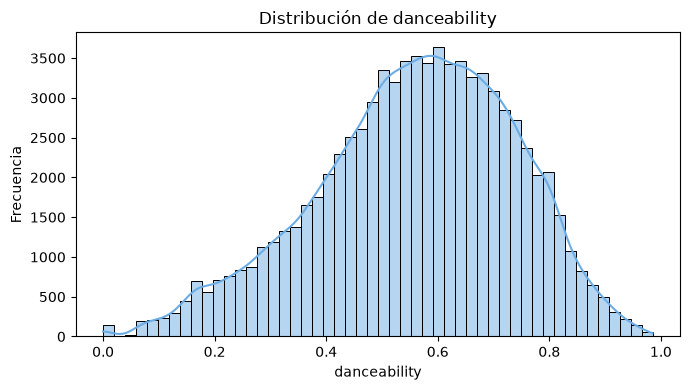

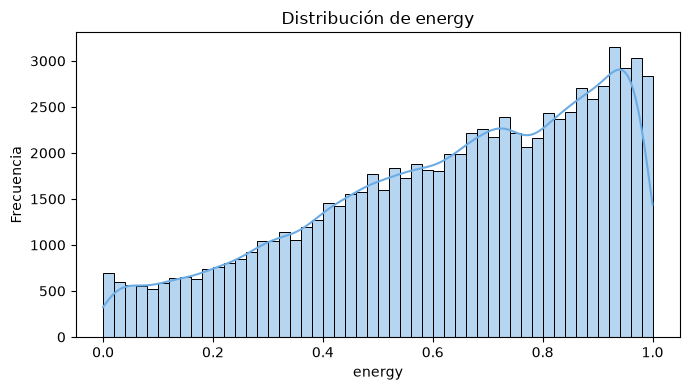

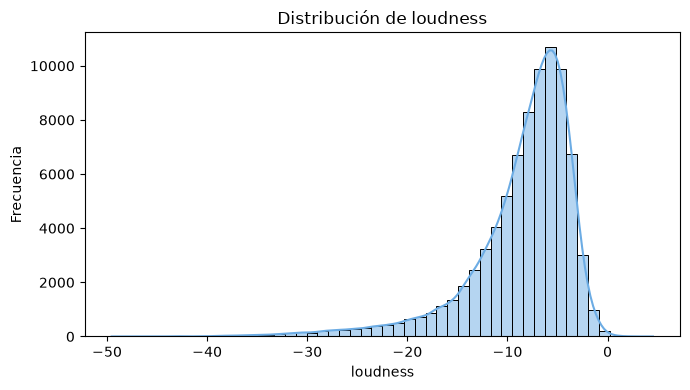

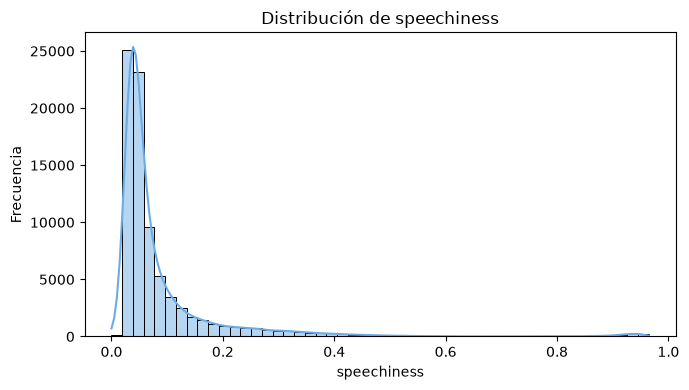

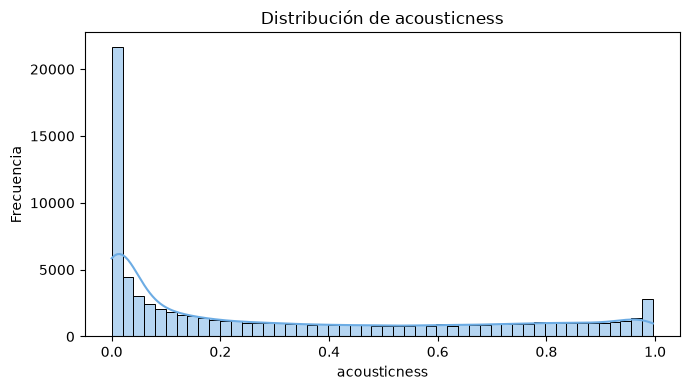

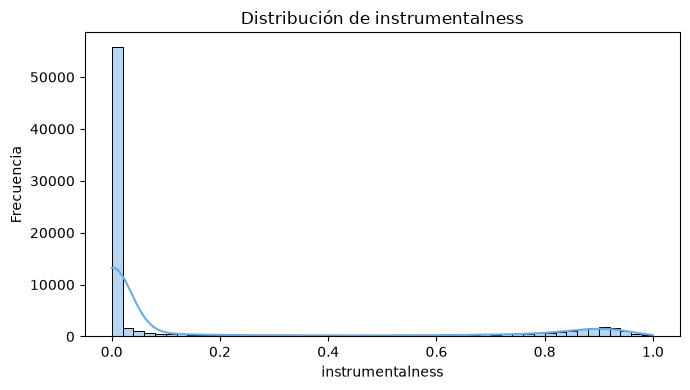

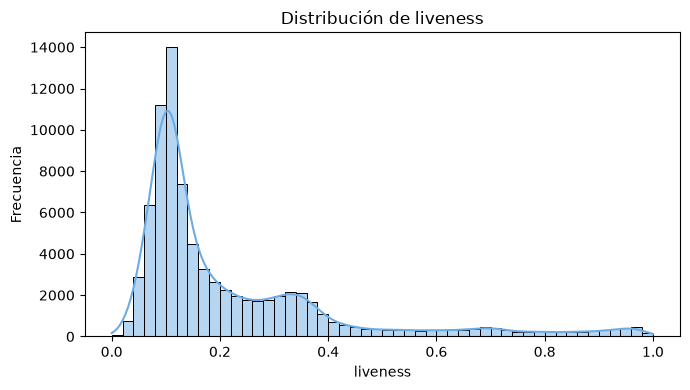

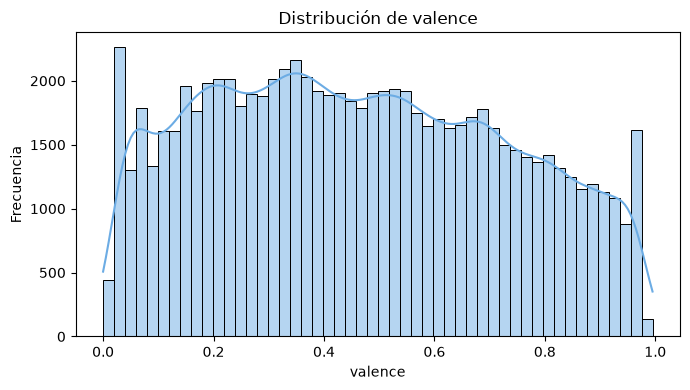

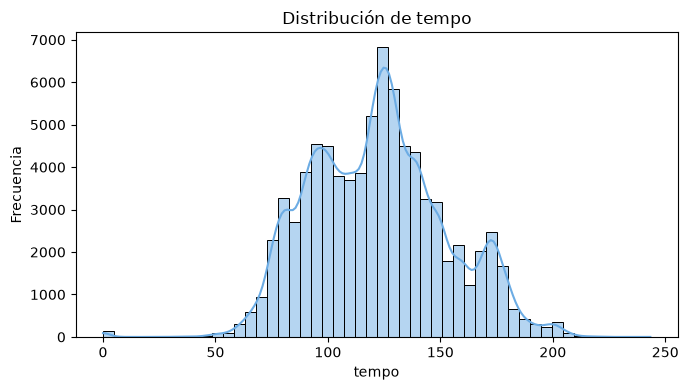

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in audio_features_cuant:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, line_kws={"color": "red"}, bins=50, color = "#6CACE4")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(f"{ruta_figuras}/hist_{col}.png", dpi=300)
    plt.show()

- Danceability: distribución unimodal, con mayor concentración en valores medios-altos. Muestra que gran parte de las canciones tienen niveles moderados o altos de bailabilidad. No se observan valores extremos ni asimtería problemática., aunque existe asimetría negativa.

- Energy: tiene una distribución inclinada hacia valores altos.

- Loudness: 

- Speechiness: distribución fuertementa assimétrica hacia la derecha, así como la curtosis, lo que indica que la mayor aprte de canciones tienen valores bajos, aunque hay un reducido grupo con valores muy altos, posiblemente asociados a rap, podcasto canciones habladas.

- Acousticness: muestra una dsitribución muy asimétrica y casi polarizada. La gran mayoría de canciones se concentran en valores muy bajos (más de al mitad de las canciones). 

- Instrumentalness: muestra una dsitribución interesante pero problemática. La mediana es prácticamente cero y el tercer cuartil apenas llega a 0,1. Aún así, existen bastantes canciones cercanas a 1 (la distribución tiene un comportamiento cercano a una variable de presencia/ausencia de instrumentalidad, siendo una variable continua con rasgos de una binaria). Puede ser una variable muy relevante para diferenciar canciones pero puede comportarse de manera no lineal.

- Liveness: también presenta asimetría positiva. La mayoría de las canciones tiene valores bajos y hay un grupo reducido de canciones con valores altos. Además de la asimetría, la curtosis es alta observando la presencia de cola derecha.

- Valence: distribución bastante amplia y equilibrada, con asimetría muy baja. Por ello, parece una variable muy útil para capturar diferencias musicales entre canciones con cargas emocionales diferentes.

- Tempo: presenta un rango muy amplio (0 a 243 BPM). Su distribución se concentra entre 90 y 150 BPM, pero existen extremos tanto bajos como altos. A diferencia del resto de variables, tempo no está en el rango 0-1, lo cuál no es un problema ya que podremos escalar cuando sea necesario.



### BOXPLOTS

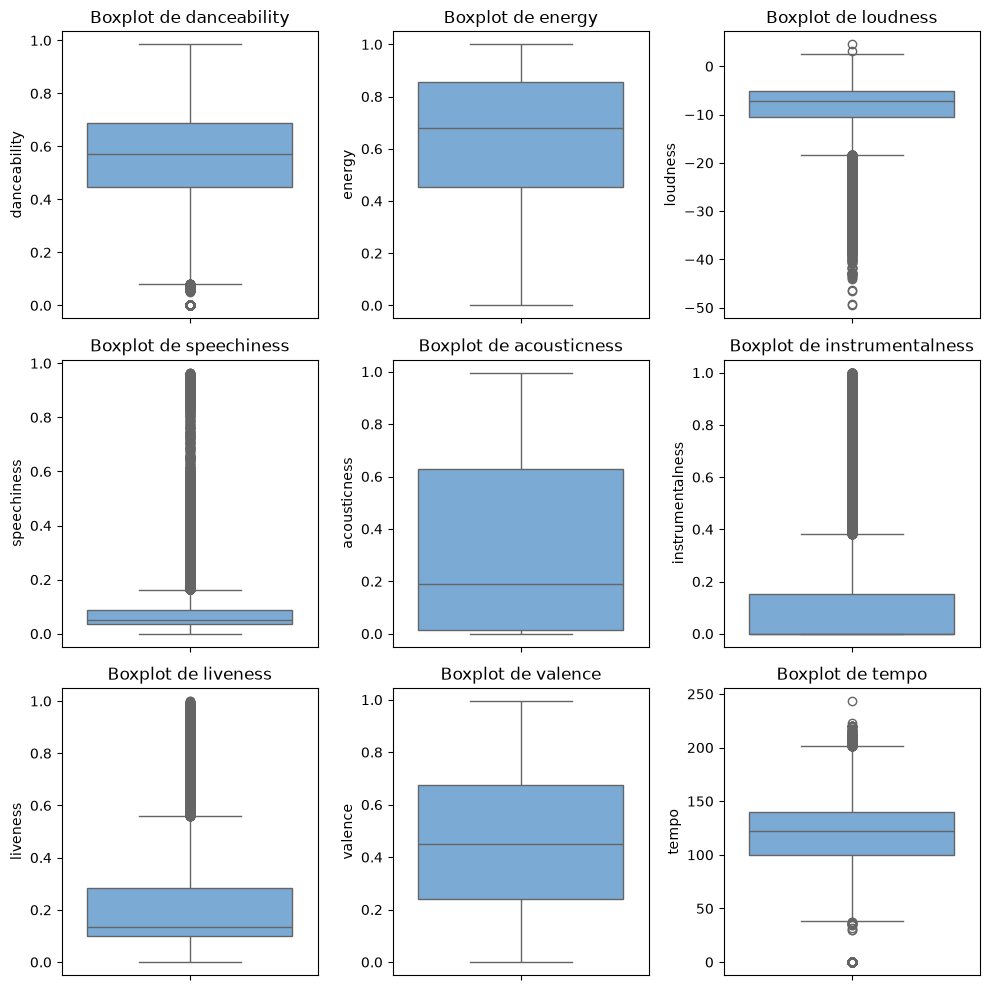

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(audio_features_cuant):
    sns.boxplot(y=df[col], color="#6CACE4", ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.savefig(f"{ruta_figuras}/boxplots.png", dpi=300)
plt.show()

### TRATAMIENTO DE OUTLIERS

#### LOUDNESS

In [27]:
print("Las 10 canciones más silenciosas:")
print(df.sort_values("loudness")[
    ["track_name", "main_artist", "loudness", "main_genre", "duration_min"]
].head(10))

print("Las 10 canciones más ruidosas:")
print(df.sort_values("loudness", ascending=False)[
    ["track_name", "main_artist", "loudness", "main_genre", "duration_min"]
].head(10))

Las 10 canciones más silenciosas:
                                         track_name               main_artist  \
44496  Soothing White Noise - Loopable With No Fade  White Noise Sleep Sounds   
38242           White Noise - Loopable With No Fade  White Noise Sleep Sounds   
42439                Ceiling Fan Sound on Low Power           Atmosphere Asmr   
15507       Cricket Sound 4 - Loopable With No Fade    White Noise for Babies   
10946       Chaconne in sol maggiore : Variazione 9              Lazar Berman   
44774                  Nap in the Afternoon Box Fan            Binaural Beats   
44314                                Loopable Woods    Relaxing Music Therapy   
40290           Sleep Sound For Babies - Underwater     Wave Sounds For Sleep   
9256                                   Wake with me              Brian Lyndon   
37039     Clean White Noise - Loopable Without Fade        White Noise Babies   

       loudness main_genre  duration_min  
44496   -49.531      sleep     

Los outliers silenciosos parecen representar canciones ambientales, de sueño, de ruido blanco, sonidos de fondo o piezas de piano muy suaves. No parecen errores de datos, sino un tipo específico de contenido sonoro. Por el momento se mantienen, aunque si en el futuro tienen un comportamiento problemático o distorsionan el espacio musical podrán ser eliminados.


Los outliers ruidosos son sospechosos porque los valores suelen estar por debajo de 0 dB. Son posibles pero indican pistas extremadamente comprimidas o saturadas. Viendo los géneros de estas canciones (club, funk, garage, iranian) hay muchas posibilidades de que efectivamente sean canciones muy comprimidas

#### TEMPO

In [28]:
print((df["tempo"] == 0).sum())

df[df["tempo"] == 0][
    ["track_name", "main_artist", "tempo", "main_genre", "duration_min"]
].head(10)

145


,track_name,main_artist,tempo,main_genre,duration_min
165,Clean White Noise - Loopable with no fade,White Noise Baby Sleep,0.0,sleep,1.50
1156,Deep Sleep Recovery Noise,Water Sound Natural White Noise,0.0,sleep,1.05
6141,The Departure,Max Richter,0.0,ambient,2.53
6927,"Hello, Dolly!",Louis Armstrong,0.0,jazz,2.45
8212,White Noise Relaxation for Calming Down Fussy ...,White Noise Baby Sleep,0.0,sleep,9.90
9203,The Early Morning Rain,White Noise Baby Sleep,0.0,sleep,1.46
12363,Loopable Pink Noise Flowing Waters,Pink Noise,0.0,sleep,3.60
12912,Weißes Rauschen: Tiefschlaf,Weißes Rauschen HD,0.0,sleep,1.57
14463,The End of Childhood (feat. Jack Liebeck),Dario Marianelli,0.0,ambient,1.22
15129,Box Fan Long Loop For Sleep,Fan Sounds,0.0,sleep,8.34


Tempo = 0 no representa una canción a 0 BPM. La PCA interpretaría esas canciones como extremadamente lentas, lo que puede deformar el espacio musical si dejamos las filas.

Es por ello que se procede a eliminar todas las canciones con tempo = 0.

In [29]:
df = df[df["tempo"] != 0].copy()

#### DURATION

In [30]:
print((df["duration_min"] > 10).sum())

df[df["duration_min"] > 10][
    ["track_name", "main_artist", "tempo", "main_genre", "duration_min"]
].sort_values(by="duration_min", ascending=False).head(10)

539


,track_name,main_artist,tempo,main_genre,duration_min
40835,Unity (Voyage Mix) Pt. 1,Tale Of Us,124.001,minimal-techno,87.29
71944,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,121.055,breakbeat,79.82
73697,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,123.180,detroit-techno,78.84
68194,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,125.044,minimal-techno,76.06
72324,House of Om - Mark Farina - Continuous Mix,Mark Farina,129.306,chicago-house,74.13
72093,Live In Tokyo - Continuous Mix,Mark Farina,128.368,chicago-house,72.33
71235,Greenhouse Construction,Mark Farina,125.434,chicago-house,72.25
69547,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman,173.938,drum-and-bass,70.77
34926,Ocean Waves Sounds,Ocean Sounds,84.788,sleep,68.67
42665,Internal Flight,Estas Tonne,159.791,guitar,64.60


Parecen tratarse de sesiones electrónicas, sonidos ambiente, mixes, etc. Probablemente no representan el mismo tipo de unidad que una canción estándar (muchas secciones distintas, los audio features mostrados son un promedio de todas esas fases). Esto podría olocar este tipo de canciones en el espacio de una forma poco comparable a otras canciones.

Sin embargo, se mantendrán por el momento para hacer una comparación de PCAs en los que incluir las filas o no.

### CORRELACIONES

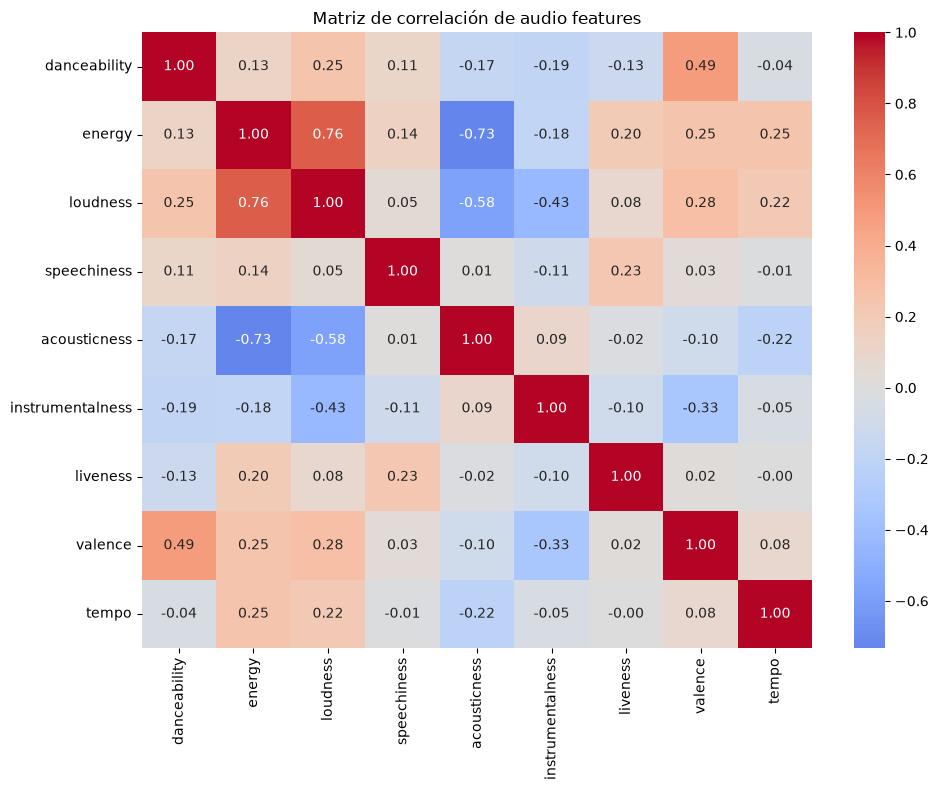

In [31]:
corr = df[audio_features_cuant].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación de audio features")
plt.tight_layout()
plt.savefig(f"{ruta_figuras}/corrplot.png", dpi=300)
plt.show()

#### OBSERVACIONES
La presencia de correlaciones fuertes y moderadas entre varias características musicales justifica la aplicación de PCA y AFE.

Del análisis de correlación podríamos extraer diferentes bloques musicales:

#### Bloque de intensidad sonora
Canciones energéticas y fuertes tienden a ser menos acústicas.

Energy - Loudness (+)

Energy - Acousticness (-)

Loudness - Acousticness (-)


#### Bloque de vibras
Canciones más bailables tienden a presentar positividad.

Danceability - Valence (+)

#### Variables más independientes
Presentan correlaciones bajas con la mayoría de variables. Deberán revisarse especialmente en el KMO individual, cargas factoriales, etc.

Speechiness

Liveness

Tempo


#### Análisis de las variables
- Danceability: variable relevante para el esapcio sensorial porque puede contribuir a diferenciar canciones más rítmicas o bailables de canciones menos enfocadas en el movimiento. Muestra correlación moderada con valence (las canciones más bailables suelen ser más positivas emocionalmente).


- Energy: fuerte correlación positiva con loudness y negativa con acousticness (sugiere que cada par de variables capta uuna dimensión común en el espacio musical).

- Speechiness: no está fuertemente correlacionada con la myoría de las variables auqnue tiene alguna correlación baja con energy, loudness, danceability, valence y especialmente liveness. Eso quiere decir que o aporta información específica no capturada por otras variables o puede ser una variable problemática al no compartir demasiada estructura común con el resto.

- Acousticness: presenta fuerte relación negativa con energy y algo menor con loudness. Puede ayuadr a separar canciones de producción más orgánica o íntima frente a canciones más eléctricas o producidas.

- Instrumentalness: se relaciona negativamente con valence y con loudness además de relaciones débiles con otras variables.

- Liveness: no muestra relaciones fuertes con la mayoría de variables. Podemos destacar la relación moderada-baja con speechiness y con energy pero parece aportar información bastante específica.

- Valence: se asocia de forma moderada con danceability y algo menos con energy y loudness. Negativamente se relaciona con instrumentalness.

- Tempo: se relaciona débilmente con energy, loudness y acousticness, puede aportar información rítmica independiente.

## VARIABLES DE CONTROL

### DESCRIPTIVA

In [32]:
df[control_features_cuant].describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,81198.0,35.245819,19.421175,0.00,21.0,35.00,49.75,100.00
duration_min,81198.0,3.858196,1.920296,0.26,2.9,3.59,4.46,87.29


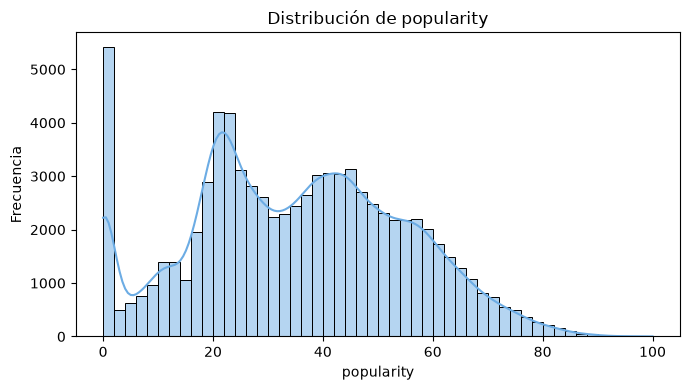

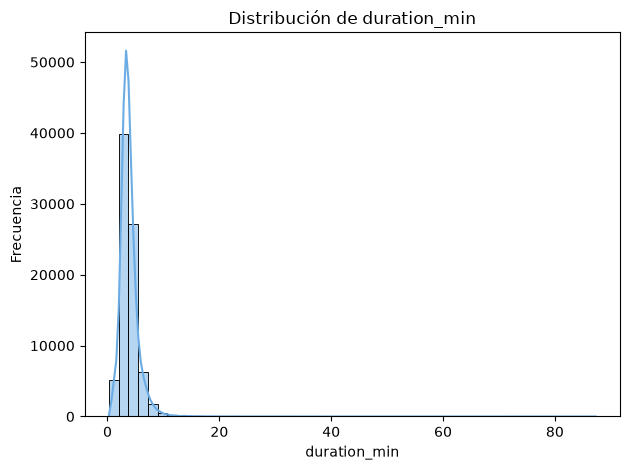

In [33]:
plt.figure(figsize=(7, 4))
for var in control_features_cuant:
    sns.histplot(df[var], bins=50, kde=True, color="#6CACE4")
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(f"{ruta_figuras}/hist_{var}.png", dpi=300)
    plt.show()

- **Popularity**: presenta una dsitribución irregular, con un grupo numeroso de canciones con popularidad 0 y una amplia concentración entre valores de 20 y 50. La acumulación en el valor 0 puede deberse a canciones poco conocidas, registros antiguos o canciones sin suficiente actividad en Spotify. No describe el contenido acústico de una canción sino su visibilidad o éxito dentro de la plataforma. No la usaremos en PCA ni AFE, pero podría ser útil para el sistema de recomendación, permitiendo diseñar modos de exploración diferentes (más o menos populares).

- **Duration_min**: la media está en los 3,82 minutos, valor razonable para las canciones. El máximo de 87,29 evidencia la presencia de outliers muy extremos. La distribución está muy concentrada en torno a duraciones estándar para las canciones, pero presenta una cola derecha muy larga (pudiendo corresponder a sesiones largars, piezas ambientales, grabaciones en directo...). La duración no es una variable acústica estrictamente hablando, puede afectar a la experiencia del usuario pero no debería definir el espacio sensorial por lo que no la incluímos en el PCA pero la mantenemos como variable de control.

In [34]:
print(f"\nDistribución de número de canciones por explicit:")
cont = df["explicit"].value_counts()
porcentajes = df["explicit"].value_counts(normalize=True).round(4)*100
tabla_frecuencias = pd.DataFrame({"Frecuencia": cont, "Porcentaje": porcentajes} )
print(tabla_frecuencias)




Distribución de número de canciones por explicit:
          Frecuencia  Porcentaje
explicit                        
False          74236       91.43
True            6962        8.57


In [35]:
columns_clean = (id_features +
                 control_features_cuant +
                 control_features_cat +
                 audio_features_cuant +
                 audio_features_cat)

df = df[columns_clean].copy()

In [36]:
df["artists"] = df["artists"].apply(
    lambda x: ";".join(x) if isinstance(x, list) else x
)

df["genres"] = df["genres"].apply(
    lambda x: ";".join(x) if isinstance(x, list) else x
)



In [37]:
os.makedirs("../data/processed/", exist_ok=True)

df.to_parquet(
    "../data/processed/songs.parquet",
    index=False,
    engine = "pyarrow"
)

print(f"Dataset guardado en data/processed/songs_clean.parquet")

print(f"Shape final dataset canciones: {df.shape}")
print(f"\nResumen del dataset limpio:")
print(df[audio_features_cuant].describe().round(3).T)


Dataset guardado en data/processed/songs_clean.parquet
Shape final dataset canciones: (81198, 24)

Resumen del dataset limpio:
                    count     mean     std     min     25%      50%      75%  \
danceability      81198.0    0.560   0.176   0.051   0.447    0.574    0.690   
energy            81198.0    0.636   0.258   0.000   0.456    0.678    0.857   
loudness          81198.0   -8.573   5.262 -46.591 -10.434   -7.259   -5.139   
speechiness       81198.0    0.089   0.117   0.022   0.036    0.049    0.087   
acousticness      81198.0    0.329   0.340   0.000   0.016    0.190    0.628   
instrumentalness  81198.0    0.184   0.331   0.000   0.000    0.000    0.149   
liveness          81198.0    0.219   0.198   0.009   0.098    0.133    0.282   
valence           81198.0    0.464   0.263   0.000   0.242    0.449    0.676   
tempo             81198.0  122.353  29.703  30.200  99.644  122.045  140.142   

                      max  
danceability        0.985  
energy          

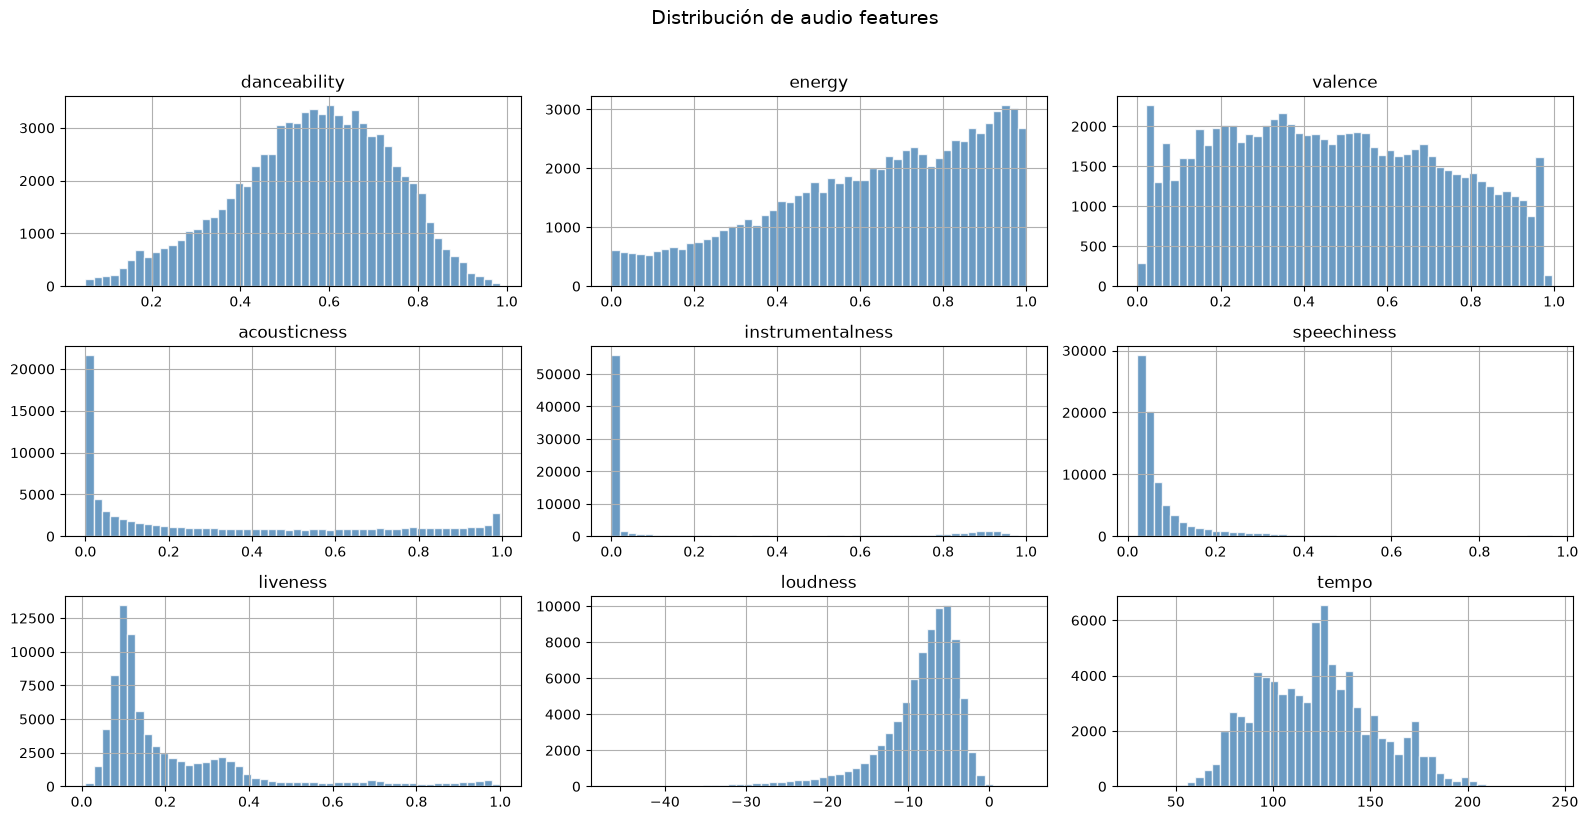

In [38]:
# Distribución de las 8 features principales
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
features_plot = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness", "loudness", "tempo"
]

for ax, feature in zip(axes.flatten(), features_plot):
    df[feature].hist(ax=ax, bins=50, color="steelblue",
                           edgecolor="white", alpha=0.8)
    ax.set_title(feature)
    ax.set_xlabel("")

plt.suptitle("Distribución de audio features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/distribuciones_features.png", dpi=150)
plt.show()

# Distribución de audio features por Género

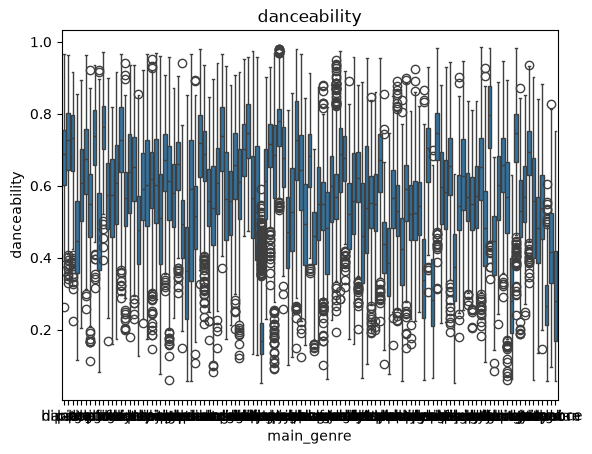

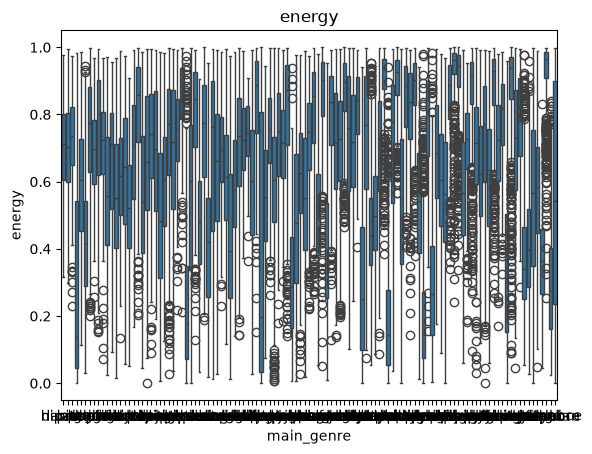

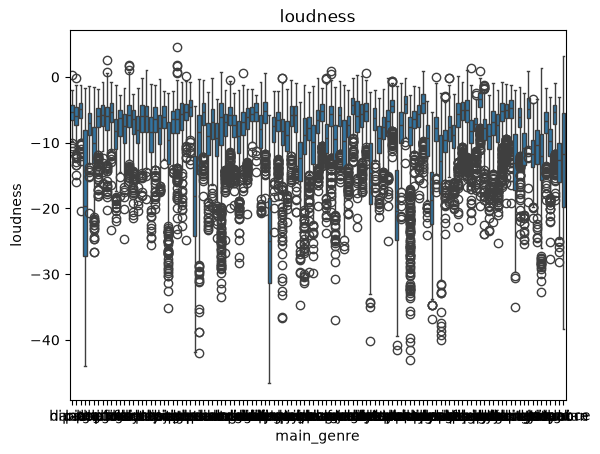

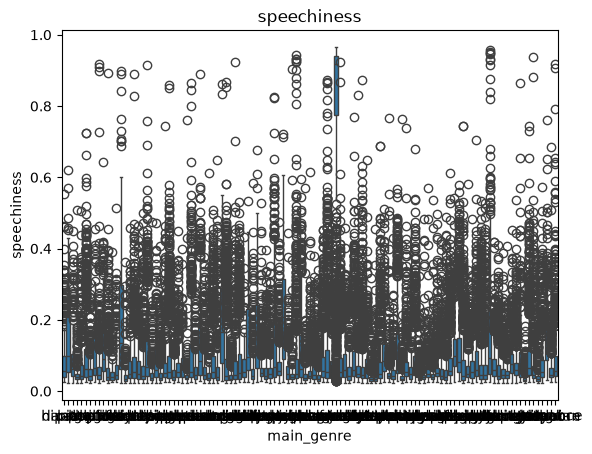

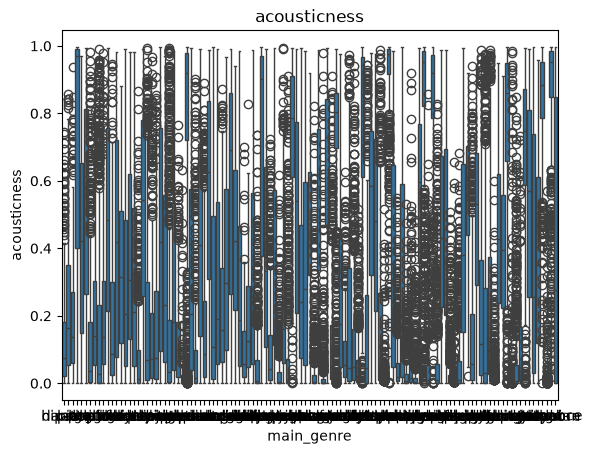

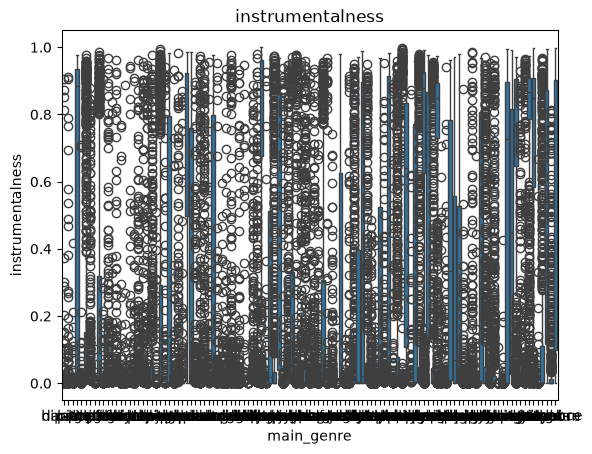

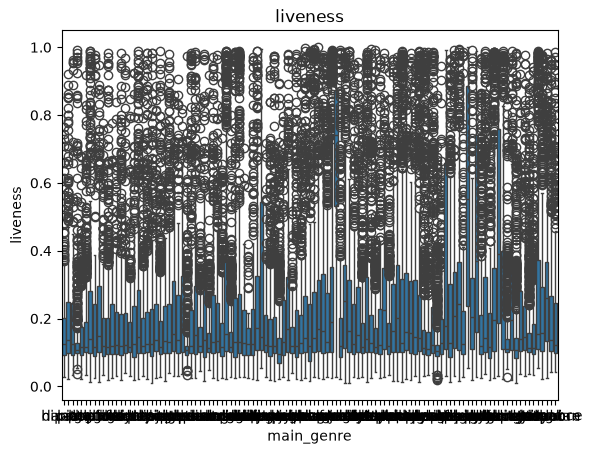

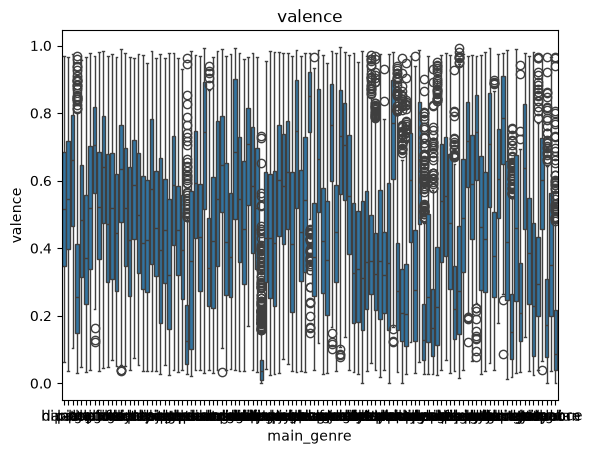

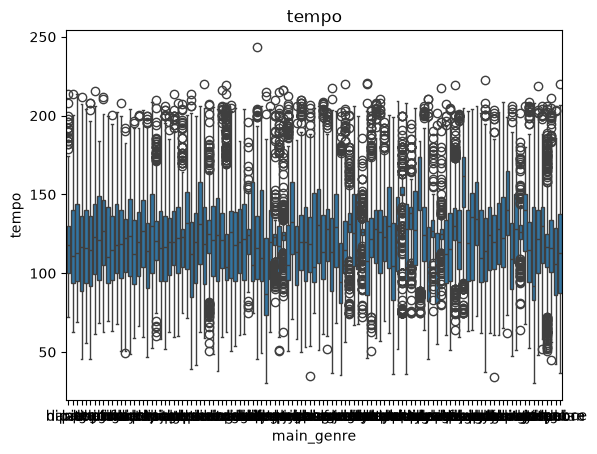

In [39]:
for col in audio_features_cuant:
    sns.boxplot(data=df, x="main_genre", y=col)
    plt.title(col)
    plt.show()

In [40]:
generos = df["main_genre"].explode().dropna().unique().tolist()
iter_gen = iter(generos)

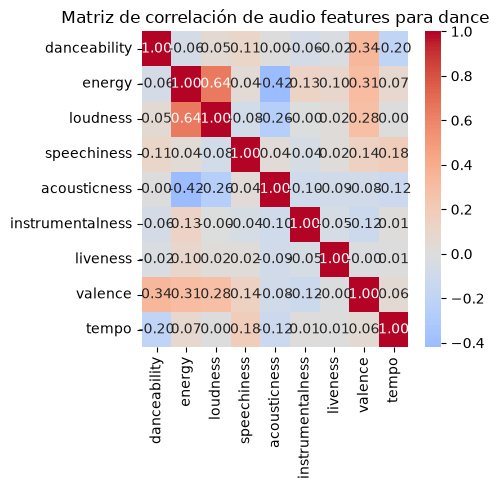

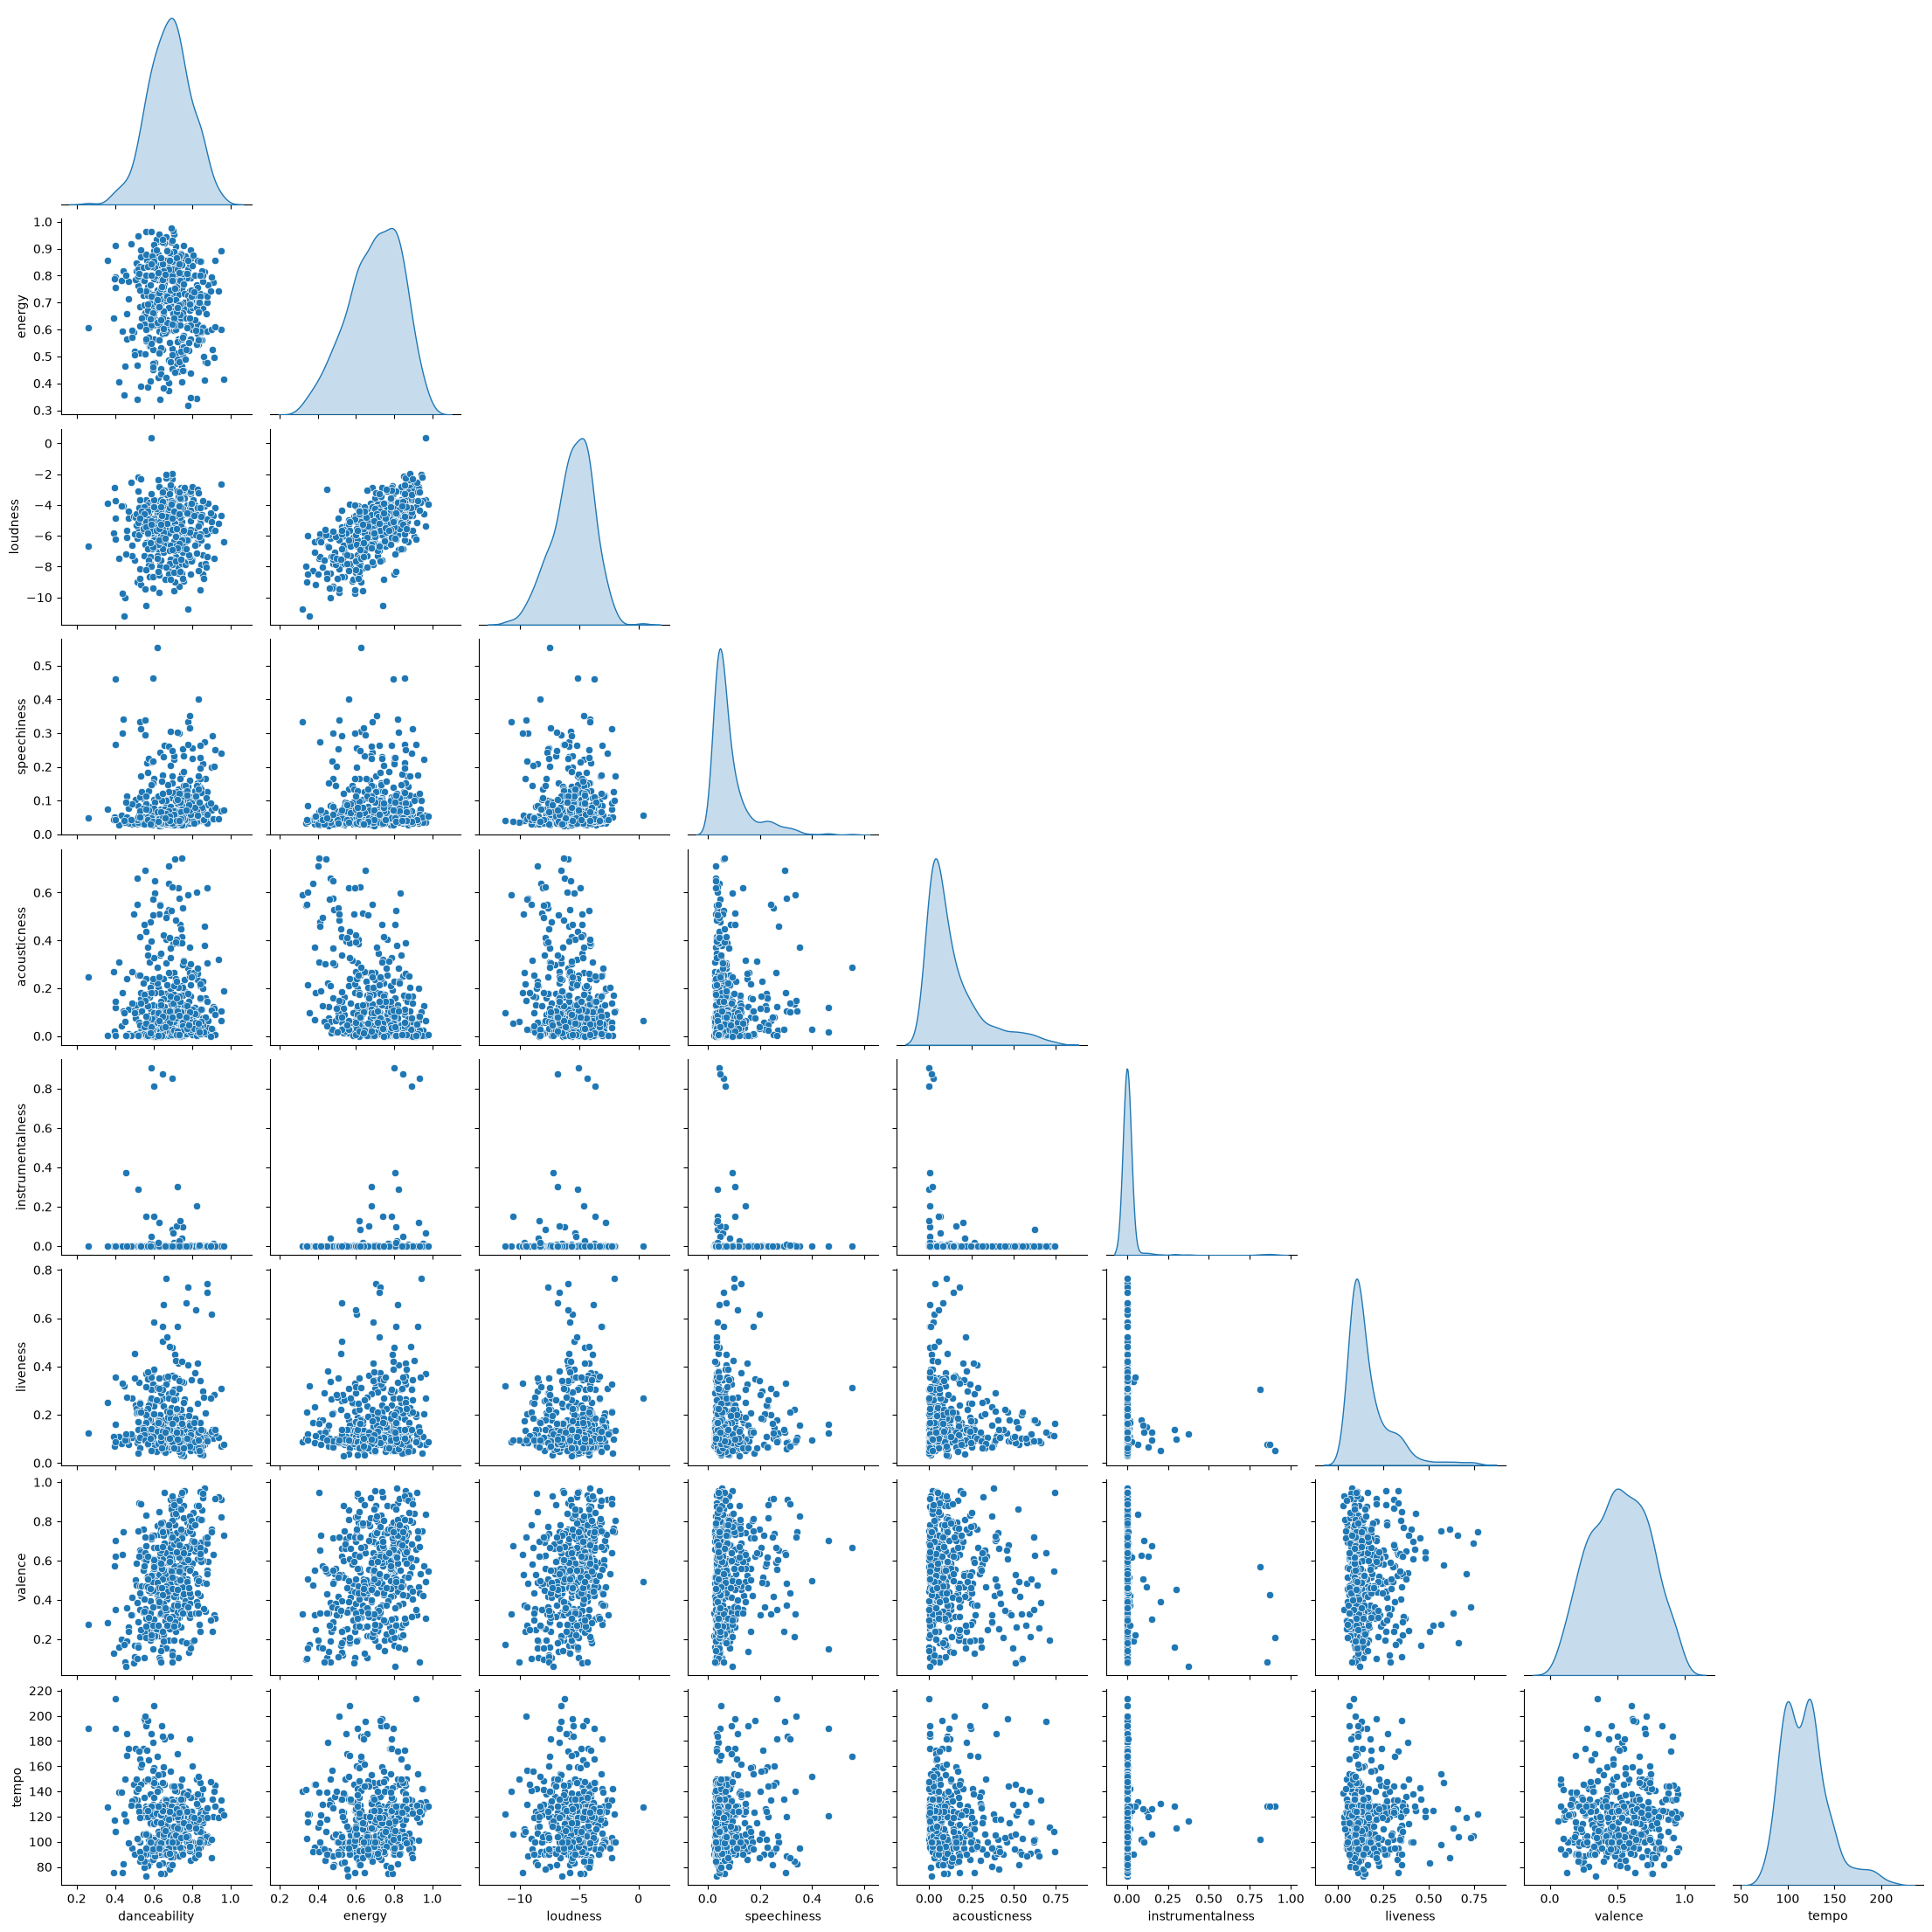

In [41]:
gen = next(iter_gen)

X_gen = df.loc[df["main_genre"] == gen, audio_features_cuant]
corr_gen = X_gen.corr()

plt.figure(figsize=(5,5))
sns.heatmap(corr_gen, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title(f"Matriz de correlación de audio features para {gen}")
plt.tight_layout()
plt.show()

sns.pairplot(
    X_gen,
    diag_kind="kde",
    corner=True
)
plt.show()



# Estudio por artista

In [42]:
artistas = df["main_artist"].explode().dropna().unique().tolist()
iter_art = iter(artistas)

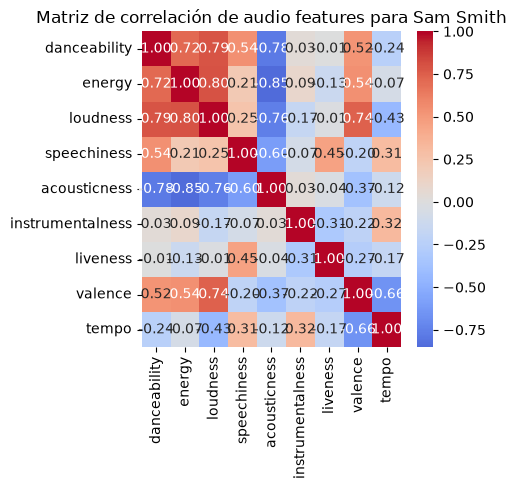

In [43]:
art = next(iter_art)

X_art = df.loc[df["main_artist"] == art, audio_features_cuant]
corr_art = X_art.corr()

plt.figure(figsize=(5,5))
sns.heatmap(corr_art, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title(f"Matriz de correlación de audio features para {art}")
plt.tight_layout()
plt.savefig(f"{ruta_figuras}/corrplot_Xgen.png", dpi=300)
plt.show()


# BOXPLOTS AUDIO FEATURES / GÉNERO

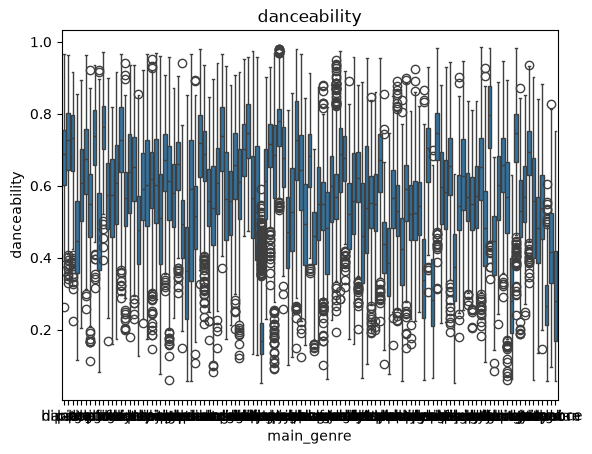

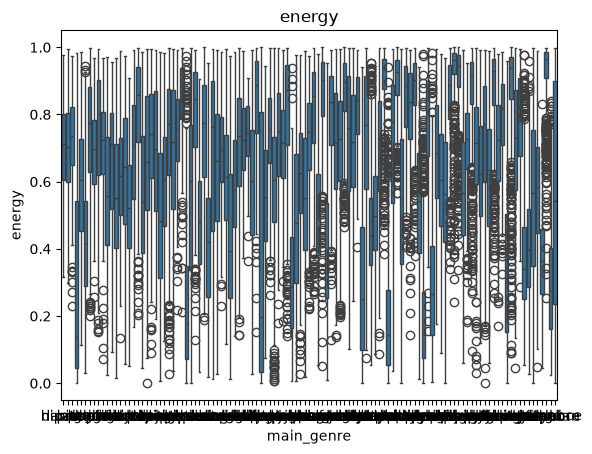

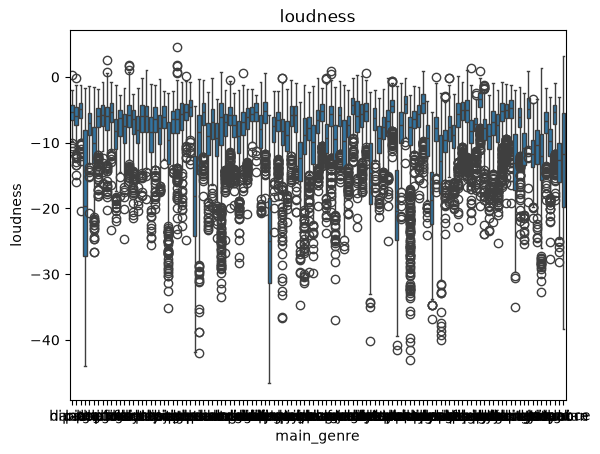

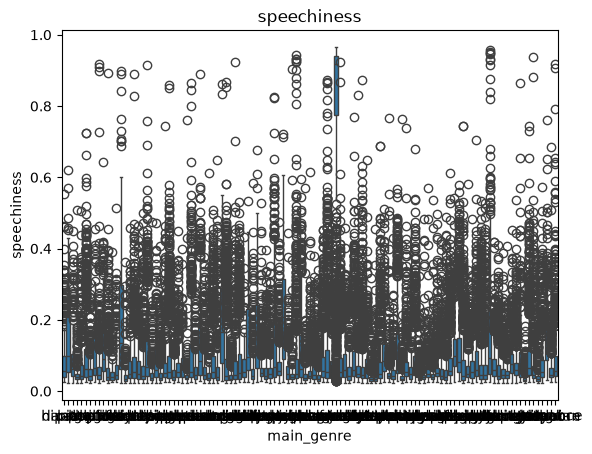

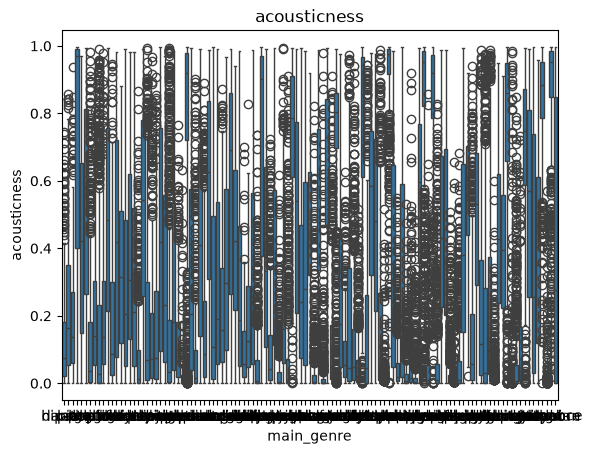

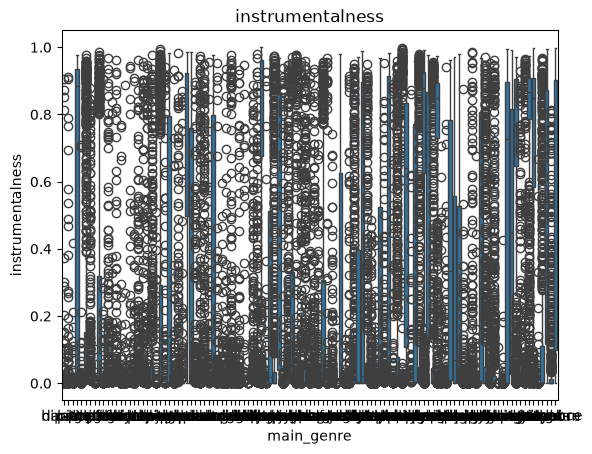

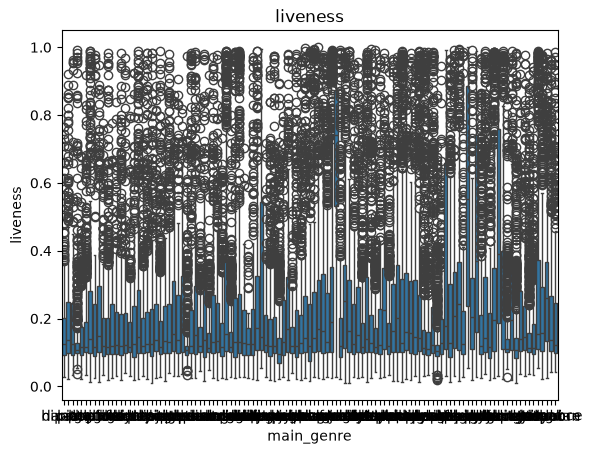

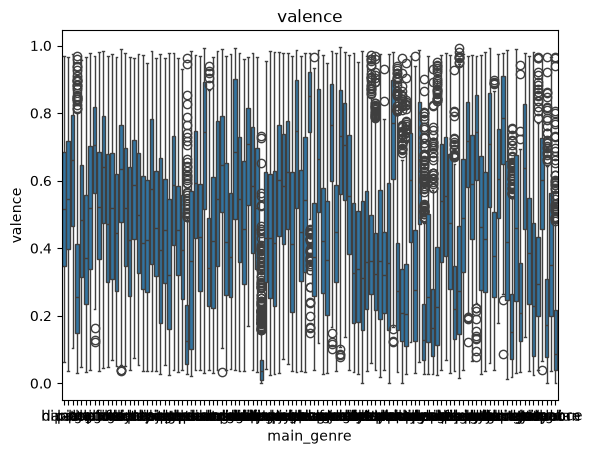

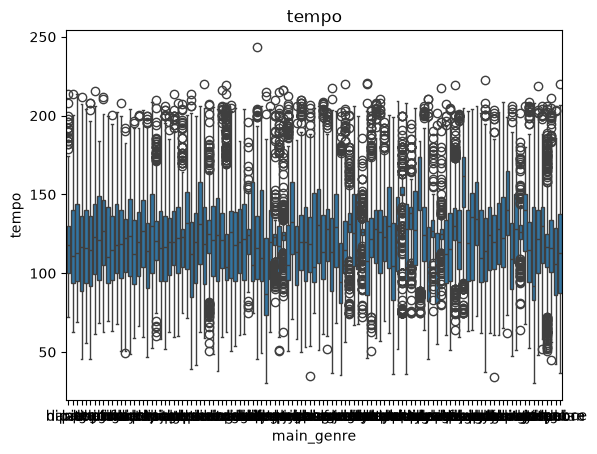

In [44]:
for col in audio_features_cuant:
    sns.boxplot(data=df, x="main_genre", y=col)
    plt.title(col)
    plt.show()